# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Shava Selvia R.S
- **Email:** shashava05@gmail.com
- **ID Dicoding:** shavel28

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perkembangan jumlah pesanan dan total nilai penjualan per bulan selama periode September 2016–Agustus 2018, dan bulan mana yang memiliki nilai penjualan tertinggi?
- **Pertanyaan 2:** Kategori produk apa yang menghasilkan nilai penjualan terbesar selama periode September 2016–Agustus 2018, dan seberapa besar kontribusinya terhadap total nilai penjualan?

## Import Semua Packages/Library yang Digunakan

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Data Wrangling

### Gathering Data

#### Load df

In [46]:
import os

data_path = "data"

print("Isi folder dataset:")
print(os.listdir(data_path))

Isi folder dataset:
['customers_dataset.csv', 'geolocation_dataset.csv', 'New Text Document.txt', 'orders_dataset.csv', 'order_items_dataset.csv', 'order_payments_dataset.csv', 'order_reviews_dataset.csv', 'products_dataset.csv', 'product_category_name_translation.csv', 'sellers_dataset.csv']


In [47]:
orders = pd.read_csv(data_path + '/orders_dataset.csv')
order_items = pd.read_csv(data_path + '/order_items_dataset.csv')
order_payments = pd.read_csv(data_path + '/order_payments_dataset.csv')
order_reviews = pd.read_csv(data_path + '/order_reviews_dataset.csv')
products = pd.read_csv(data_path + '/products_dataset.csv')
sellers = pd.read_csv(data_path + '/sellers_dataset.csv')
geolocation = pd.read_csv(data_path + '/geolocation_dataset.csv')
translation = pd.read_csv(
    data_path + '/product_category_name_translation.csv'
)
customers = pd.read_csv(data_path + '/customers_dataset.csv')

print("Semua dataset berhasil dimuat.")
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Order Payments:", order_payments.shape)
print("Order Reviews:", order_reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)
print("Translation:", translation.shape)

Semua dataset berhasil dimuat.
Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Geolocation: (1000163, 5)
Translation: (71, 2)


**Insight:** (Opsional)

- Dataset terdiri dari 9 tabel yang menggambarkan aktivitas e-commerce, mulai dari informasi pelanggan, pesanan, produk, pembayaran, penjual, hingga ulasan pelanggan.
- Analisis utama menggunakan data `orders`, `order_items`, `products`, dan `customers` karena tabel tersebut menyediakan informasi yang diperlukan untuk menganalisis transaksi, nilai penjualan, kategori produk, dan perilaku pelanggan.
- Setiap tabel memiliki struktur dan karakteristik yang berbeda sehingga perlu dilakukan pemeriksaan kualitas data sebelum proses analisis.

### Assessing Data

#### Identifying Data Quality Problems

In [48]:
# 1. Memeriksa struktur dan tipe data
print("=== INFORMASI DATA ===")
print("\nORDERS")
orders.info()

print("\nORDER ITEMS")
order_items.info()

print("\nPRODUCTS")
products.info()

# 2. Memeriksa missing value
print("\n=== MISSING VALUE ===")
print("\nOrders:")
display(orders.isna().sum().sort_values(ascending=False))

print("\nOrder Items:")
display(order_items.isna().sum().sort_values(ascending=False))

print("\nProducts:")
display(products.isna().sum().sort_values(ascending=False))

# 3. Memeriksa duplicate
print("\n=== DUPLICATE DATA ===")
print("Orders:", orders.duplicated().sum())
print("Order Items:", order_items.duplicated().sum())
print("Products:", products.duplicated().sum())
print("Payments:", order_payments.duplicated().sum())
print("Reviews:", order_reviews.duplicated().sum())
print("Customers:", customers.duplicated().sum())

# 4. Memeriksa statistik numerik dan potensi outlier
print("\n=== STATISTIK NUMERIK ORDER ITEMS ===")
display(order_items[['price', 'freight_value']].describe())

q1 = order_items['price'].quantile(0.25)
q3 = order_items['price'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)
outlier_price_count = (order_items['price'] > upper_bound).sum()

print(f"Potensi outlier price berdasarkan IQR: {outlier_price_count} baris")
print(f"Batas atas IQR: {upper_bound:.2f}")

# 5. Memeriksa tipe kolom tanggal
print("\n=== TIPE DATA TANGGAL ===")
display(
    orders[
        [
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ].dtypes
)

=== INFORMASI DATA ===

ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB

ORDER ITEMS
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64


Order Items:


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


Products:


product_category_name         610
product_description_lenght    610
product_name_lenght           610
product_photos_qty            610
product_weight_g                2
product_height_cm               2
product_length_cm               2
product_width_cm                2
product_id                      0
dtype: int64


=== DUPLICATE DATA ===
Orders: 0
Order Items: 0
Products: 0
Payments: 0
Reviews: 0
Customers: 0

=== STATISTIK NUMERIK ORDER ITEMS ===


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


Potensi outlier price berdasarkan IQR: 8427 baris
Batas atas IQR: 277.40

=== TIPE DATA TANGGAL ===


order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

**Steps to Take:**

- Mengonversi seluruh kolom tanggal pada dataset `orders` menjadi tipe `datetime`.
- Menghapus data duplikat apabila ditemukan.
- Menangani missing value pada `product_category_name` dengan label `unknown`.
- Missing value pada tanggal pengiriman tidak diimputasi karena dapat menunjukkan pesanan yang belum menyelesaikan proses pengiriman dan kolom tersebut tidak menjadi dasar utama analisis penjualan.
- Memeriksa potensi outlier pada `price`. Nilai yang sangat tinggi tidak langsung dihapus karena dapat merupakan transaksi produk dengan harga tinggi yang valid.
- Hanya pesanan dengan status `delivered` yang digunakan dalam analisis penjualan agar nilai penjualan merepresentasikan transaksi yang berhasil diselesaikan.

**Insight:**

- Ditemukan missing value pada beberapa kolom, terutama informasi pengiriman pada `orders` dan atribut produk pada `products`.
- Kolom tanggal pada `orders` masih bertipe `object` sehingga perlu dikonversi menjadi `datetime`.
- Tidak ditemukan data duplikat pada tabel utama yang diperiksa.
- Nilai maksimum `price` jauh lebih tinggi dibandingkan kuartil data sehingga teridentifikasi sebagai potensi outlier. Nilai tersebut tidak langsung dihapus karena belum dapat dinyatakan sebagai kesalahan data tanpa konteks bisnis.

### Cleaning Data

#### Fixing Identified Data Quality Problems

In [49]:
# Membuat salinan dataset
orders_clean = orders.copy()
order_items_clean = order_items.copy()
order_payments_clean = order_payments.copy()
order_reviews_clean = order_reviews.copy()
products_clean = products.copy()
customers_clean = customers.copy()

# Menghapus data duplikat
orders_clean.drop_duplicates(inplace=True)
order_items_clean.drop_duplicates(inplace=True)
order_payments_clean.drop_duplicates(inplace=True)
order_reviews_clean.drop_duplicates(inplace=True)
products_clean.drop_duplicates(inplace=True)
customers_clean.drop_duplicates(inplace=True)

# Konversi kolom tanggal
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for column in date_columns:
    orders_clean[column] = pd.to_datetime(
        orders_clean[column],
        errors='coerce'
    )

# Menangani missing value kategori produk
products_clean['product_category_name'] = (
    products_clean['product_category_name']
    .fillna('unknown')
)

# Menggabungkan terjemahan kategori produk
products_clean = products_clean.merge(
    translation,
    on='product_category_name',
    how='left'
)

products_clean['product_category_name_english'] = (
    products_clean['product_category_name_english']
    .fillna('unknown')
)

print("Cleaning data selesai.")

Cleaning data selesai.


In [50]:
print("=== HASIL CLEANING ===")
print("Duplicate Orders:", orders_clean.duplicated().sum())
print("Duplicate Order Items:", order_items_clean.duplicated().sum())
print("Duplicate Products:", products_clean.duplicated().sum())
print("Duplicate Customers:", customers_clean.duplicated().sum())

print("\nTipe data tanggal:")
display(
    orders_clean[
        [
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ].dtypes
)

print("\nMissing value kategori produk setelah cleaning:")
print(products_clean['product_category_name'].isna().sum())

=== HASIL CLEANING ===
Duplicate Orders: 0
Duplicate Order Items: 0
Duplicate Products: 0
Duplicate Customers: 0

Tipe data tanggal:


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


Missing value kategori produk setelah cleaning:
0


**Insight:** (Opsional)

- Pemeriksaan setelah proses cleaning menunjukkan tidak terdapat data duplikat pada dataset utama yang digunakan.
- Kolom tanggal pada dataset `orders` telah dikonversi ke tipe `datetime` sehingga dapat digunakan untuk analisis berdasarkan waktu.
- Missing value pada `product_category_name` telah ditangani dengan label `unknown`.
- Nilai ekstrem pada variabel `price` tetap dipertahankan karena belum terdapat bukti bahwa data tersebut merupakan kesalahan pencatatan.
- Dataset hasil cleaning telah siap digunakan untuk proses Exploratory Data Analysis.

## Exploratory Data Analysis (EDA)

### Explore Monthly Sales Performance and Product Categories

Jumlah baris setelah penggabungan: 110197
Jumlah order: 96478
Jumlah customer: 96478
Periode analisis: 2016-09 sampai 2018-08


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,sales_value,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumery,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,auto,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,stationery,28.62,2018-02


Statistik Deskriptif


,price,freight_value,sales_value
count,110197.000000,110197.000000,110197.000000
mean,119.980563,19.948598,139.929161
std,182.299446,15.698136,189.319151
min,0.850000,0.000000,6.080000
25%,39.900000,13.080000,55.180000
50%,74.900000,16.260000,92.130000
75%,134.170000,21.150000,157.510000
max,6735.000000,409.680000,6929.310000


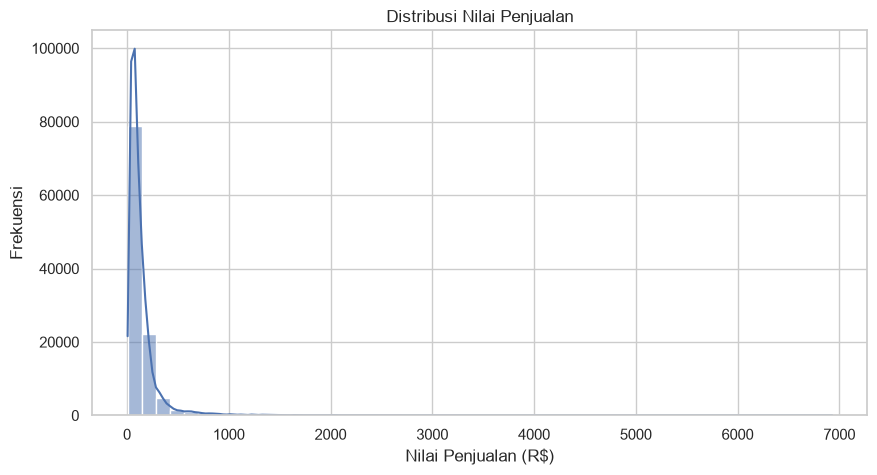

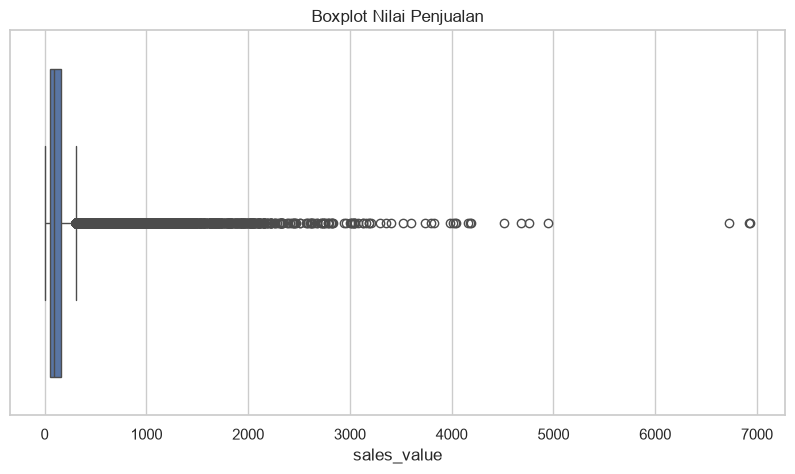

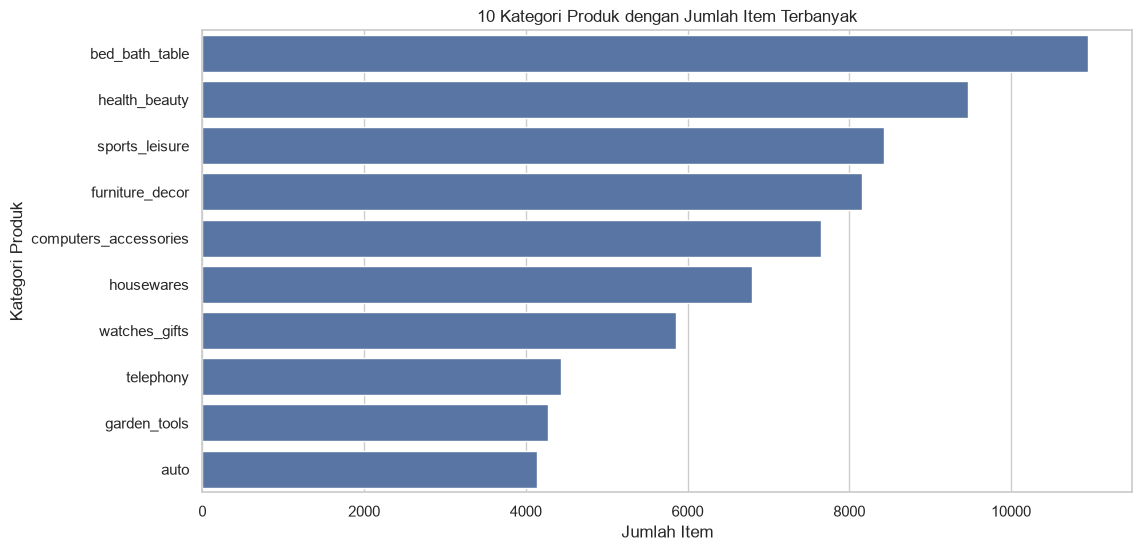

,price,freight_value,sales_value
price,1.000000,0.412722,0.997144
freight_value,0.412722,1.000000,0.480337
sales_value,0.997144,0.480337,1.000000


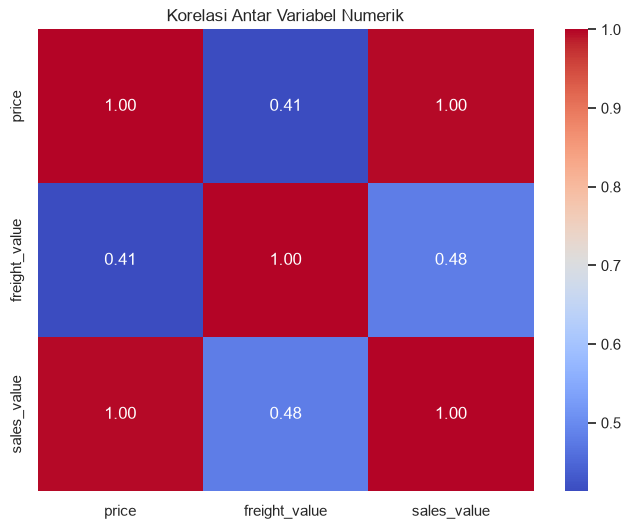

,month,total_orders,total_sales
0,2016-09,1,143.46
1,2016-10,265,46490.66
2,2016-12,1,19.62
3,2017-01,750,127482.37
4,2017-02,1653,271239.32
5,2017-03,2546,414330.95
6,2017-04,2303,390812.40
7,2017-05,3546,566851.40
8,2017-06,3135,490050.37
9,2017-07,3872,566299.08


,product_category_name_english,total_orders,total_sales,contribution_percentage
43,health_beauty,8647,1412089.53,9.157654
71,watches_gifts,5495,1264333.12,8.199427
7,bed_bath_table,9272,1225209.26,7.945702
65,sports_leisure,7530,1118256.91,7.252097
15,computers_accessories,6530,1032723.77,6.697399
39,furniture_decor,6307,880329.92,5.709098
49,housewares,5743,758392.25,4.918310
20,cool_stuff,3559,691680.89,4.485675
5,auto,3810,669454.75,4.341534
42,garden_tools,3448,567145.68,3.678042


In [51]:
# Menggabungkan data orders dan order_items

sales = orders_clean.merge(
    order_items_clean,
    on='order_id',
    how='inner'
)


# Menambahkan informasi kategori produk

sales = sales.merge(
    products_clean[
        [
            'product_id',
            'product_category_name_english'
        ]
    ],
    on='product_id',
    how='left'
)


# Mengambil pesanan yang berhasil dikirim

sales = sales[
    sales['order_status'] == 'delivered'
].copy()


# Menghitung nilai penjualan

sales['sales_value'] = (
    sales['price'] +
    sales['freight_value']
)


# Membuat periode bulan

sales['month'] = (
    sales['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)


# Informasi dasar data

print(
    "Jumlah baris setelah penggabungan:",
    len(sales)
)

print(
    "Jumlah order:",
    sales['order_id'].nunique()
)

print(
    "Jumlah customer:",
    sales['customer_id'].nunique()
)

print(
    "Periode analisis:",
    sales['month'].min(),
    "sampai",
    sales['month'].max()
)


display(sales.head())


# ==================================================
# EDA UNIVARIATE
# ==================================================

print("Statistik Deskriptif")

display(
    sales[
        [
            'price',
            'freight_value',
            'sales_value'
        ]
    ].describe()
)


# Distribusi nilai penjualan

plt.figure(figsize=(10, 5))

sns.histplot(
    data=sales,
    x='sales_value',
    bins=50,
    kde=True
)

plt.title('Distribusi Nilai Penjualan')

plt.xlabel('Nilai Penjualan (R$)')

plt.ylabel('Frekuensi')

plt.show()


# Boxplot untuk melihat outlier

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=sales['sales_value']
)

plt.title('Boxplot Nilai Penjualan')

plt.show()


# ==================================================
# EDA KATEGORIKAL
# ==================================================

top_category_frequency = (
    sales[
        'product_category_name_english'
    ]
    .value_counts()
    .head(10)
)


plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_category_frequency.values,
    y=top_category_frequency.index
)

plt.title(
    '10 Kategori Produk dengan Jumlah Item Terbanyak'
)

plt.xlabel('Jumlah Item')

plt.ylabel('Kategori Produk')

plt.show()


# ==================================================
# EDA MULTIVARIATE
# ==================================================

numeric_columns = [
    'price',
    'freight_value',
    'sales_value'
]


correlation_matrix = (
    sales[numeric_columns]
    .corr()
)


display(correlation_matrix)


plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Korelasi Antar Variabel Numerik'
)

plt.show()


# ==================================================
# ANALISIS PENJUALAN BULANAN
# ==================================================

monthly_sales = (
    sales
    .groupby('month')
    .agg(
        total_orders=(
            'order_id',
            'nunique'
        ),
        total_sales=(
            'sales_value',
            'sum'
        )
    )
    .reset_index()
)


display(monthly_sales)


# ==================================================
# ANALISIS KATEGORI PRODUK
# ==================================================

category_sales = (
    sales
    .groupby(
        'product_category_name_english'
    )
    .agg(
        total_orders=(
            'order_id',
            'nunique'
        ),
        total_sales=(
            'sales_value',
            'sum'
        )
    )
    .reset_index()
    .sort_values(
        'total_sales',
        ascending=False
    )
)


category_sales[
    'contribution_percentage'
] = (
    category_sales['total_sales']
    /
    category_sales['total_sales'].sum()
    * 100
)


display(
    category_sales.head(10)
)

**Insight:** (Opsional)

- Analisis dilakukan menggunakan 110.197 baris data transaksi dari 96.478 pesanan dengan status `delivered`.
- Periode transaksi yang dianalisis mencakup September 2016 hingga Agustus 2018.
- Distribusi nilai penjualan menunjukkan bahwa sebagian besar transaksi berada pada nilai rendah hingga menengah, sedangkan sebagian kecil transaksi memiliki nilai yang jauh lebih tinggi.
- Boxplot menunjukkan adanya nilai ekstrem pada variabel `sales_value`. Nilai tersebut tetap dipertahankan karena dapat merepresentasikan transaksi dengan harga produk yang tinggi.
- Distribusi kategori produk menunjukkan bahwa jumlah transaksi tidak tersebar secara merata pada setiap kategori.
- Analisis korelasi digunakan untuk melihat hubungan antara `price`, `freight_value`, dan `sales_value`. Variabel `sales_value` memiliki hubungan langsung dengan `price` dan `freight_value` karena nilai tersebut dihitung dari kedua variabel tersebut.
- Hasil eksplorasi kemudian digunakan sebagai dasar untuk menganalisis tren penjualan bulanan dan performa kategori produk.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Bagaimana perkembangan jumlah pesanan dan total nilai penjualan per bulan selama periode September 2016–Agustus 2018, dan bulan mana yang memiliki nilai penjualan tertinggi?

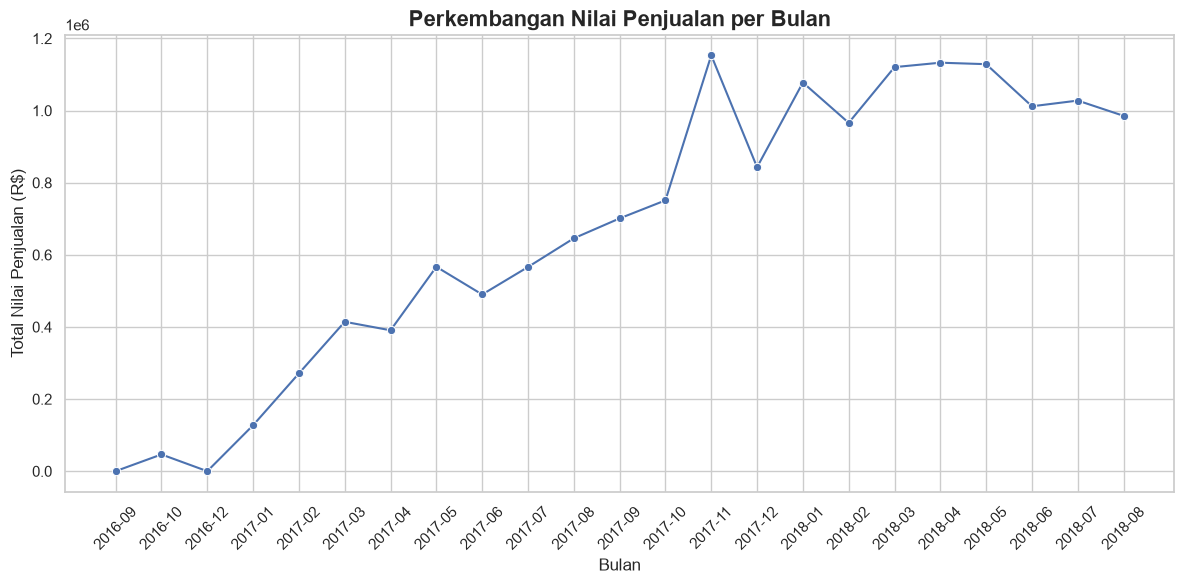

Bulan dengan nilai penjualan tertinggi: 2017-11
Total nilai penjualan: R$ 1,153,364.20


In [52]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x='month',
    y='total_sales',
    marker='o'
)

plt.title(
    'Perkembangan Nilai Penjualan per Bulan',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Bulan')

plt.ylabel('Total Nilai Penjualan (R$)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


highest_month = monthly_sales.loc[
    monthly_sales['total_sales'].idxmax()
]


print(
    "Bulan dengan nilai penjualan tertinggi:",
    highest_month['month']
)

print(
    f"Total nilai penjualan: "
    f"R$ {highest_month['total_sales']:,.2f}"
)

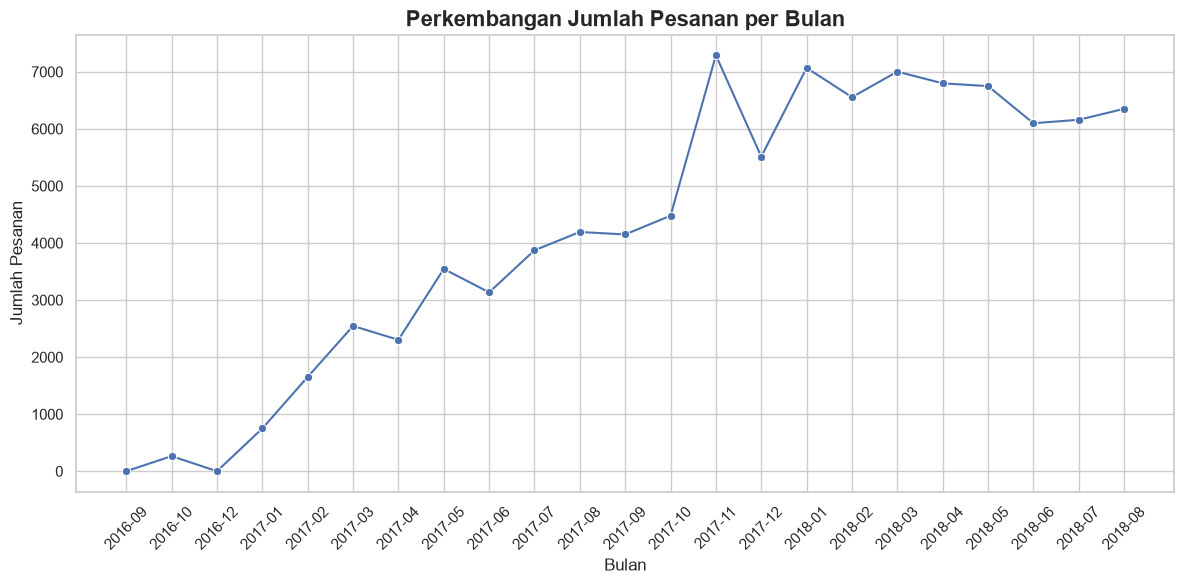

Bulan dengan jumlah pesanan tertinggi: 2017-11
Jumlah pesanan: 7,289


In [53]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x='month',
    y='total_orders',
    marker='o'
)

plt.title(
    'Perkembangan Jumlah Pesanan per Bulan',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Bulan')

plt.ylabel('Jumlah Pesanan')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


highest_order_month = monthly_sales.loc[
    monthly_sales['total_orders'].idxmax()
]

print(
    "Bulan dengan jumlah pesanan tertinggi:",
    highest_order_month['month']
)

print(
    f"Jumlah pesanan: "
    f"{highest_order_month['total_orders']:,}"
)

**Insight:**

- Performa penjualan mengalami fluktuasi selama periode September 2016 hingga Agustus 2018.
- Nilai penjualan tertinggi terjadi pada November 2017 dengan total sebesar R$ 1.153.364,20.
- Jumlah pesanan juga berubah dari bulan ke bulan dan menunjukkan peningkatan aktivitas transaksi pada sebagian besar periode tahun 2017 hingga 2018.
- Pola ini menunjukkan bahwa terdapat periode tertentu dengan permintaan pelanggan yang lebih tinggi dibandingkan bulan lainnya.

### Pertanyaan 2:

Kategori produk apa yang menghasilkan nilai penjualan terbesar selama periode September 2016–Agustus 2018, dan seberapa besar kontribusinya terhadap total nilai penjualan?

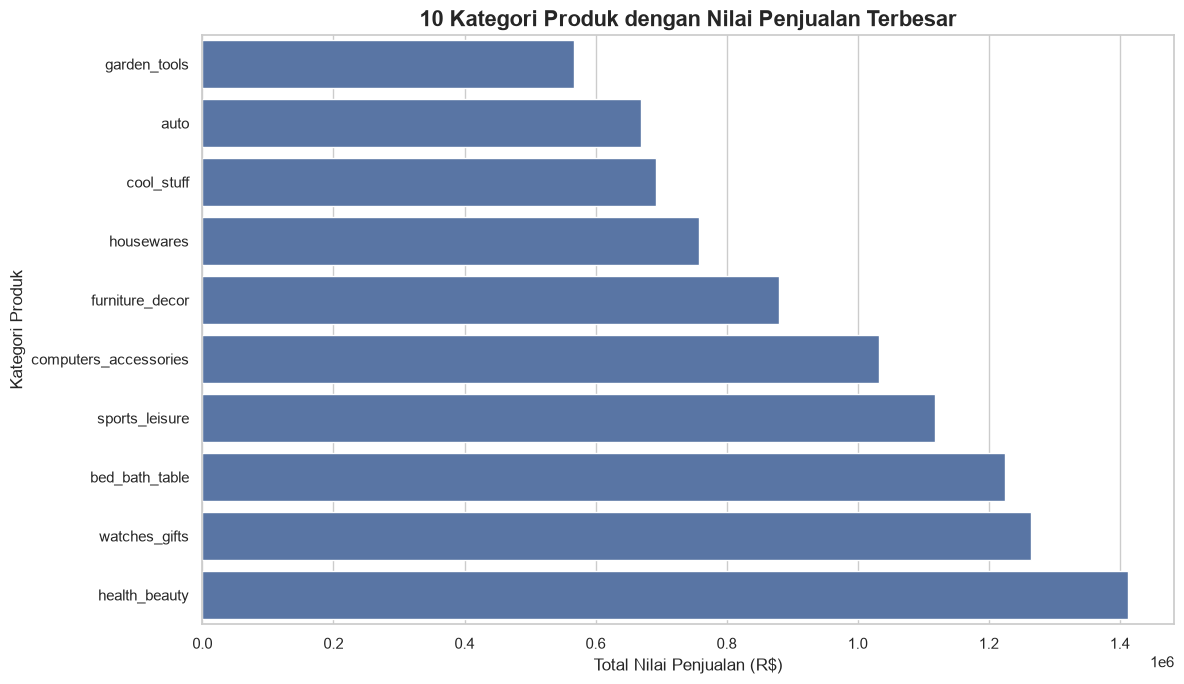

Kategori dengan nilai penjualan terbesar: health_beauty
Total nilai penjualan: R$ 1,412,089.53
Kontribusi terhadap total: 9.16%


In [54]:
top10_category = (
    category_sales
    .head(10)
    .sort_values(
        'total_sales',
        ascending=True
    )
)


plt.figure(figsize=(12, 7))

sns.barplot(
    data=top10_category,
    x='total_sales',
    y='product_category_name_english'
)

plt.title(
    '10 Kategori Produk dengan Nilai Penjualan Terbesar',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Total Nilai Penjualan (R$)'
)

plt.ylabel(
    'Kategori Produk'
)

plt.tight_layout()

plt.show()


top_category = category_sales.iloc[0]


print(
    "Kategori dengan nilai penjualan terbesar:",
    top_category[
        'product_category_name_english'
    ]
)

print(
    f"Total nilai penjualan: "
    f"R$ {top_category['total_sales']:,.2f}"
)

print(
    f"Kontribusi terhadap total: "
    f"{top_category['contribution_percentage']:.2f}%"
)

**Insight:** (Opsional)

- Kategori `health_beauty` menjadi kategori dengan nilai penjualan terbesar selama periode analisis.
- Total nilai penjualan kategori tersebut mencapai R$ 1.412.089,53.
- Kontribusinya terhadap keseluruhan nilai penjualan mencapai 9,16%.
- Hasil ini menunjukkan bahwa kategori `health_beauty` memiliki potensi penting dalam strategi penjualan dan dapat menjadi salah satu kategori prioritas dalam pengelolaan promosi maupun persediaan.

## Analisis Lanjutan (Opsional)

RFM Analysis digunakan untuk memahami perilaku pelanggan berdasarkan tiga indikator:

- **Recency:** jumlah hari sejak transaksi terakhir pelanggan.
- **Frequency:** jumlah transaksi yang dilakukan pelanggan.
- **Monetary:** total nilai penjualan pelanggan.

Untuk menghindari kesalahan identitas pelanggan, analisis menggunakan `customer_unique_id` dari `customers_dataset.csv`. Kolom `customer_id` pada dataset Olist merupakan identitas yang terkait dengan pesanan, sehingga bukan pilihan yang tepat untuk menghitung pelanggan unik pada RFM.

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,Potential Loyalists
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,Lost Customers


,Segment,Customers,Percentage
0,At Risk,22357,23.947600
1,Needs Attention,18672,20.000428
2,Loyal Customers,15904,17.035498
3,Lost Customers,14986,16.052186
4,Potential Loyalists,14984,16.050044
5,Champions,6455,6.914244


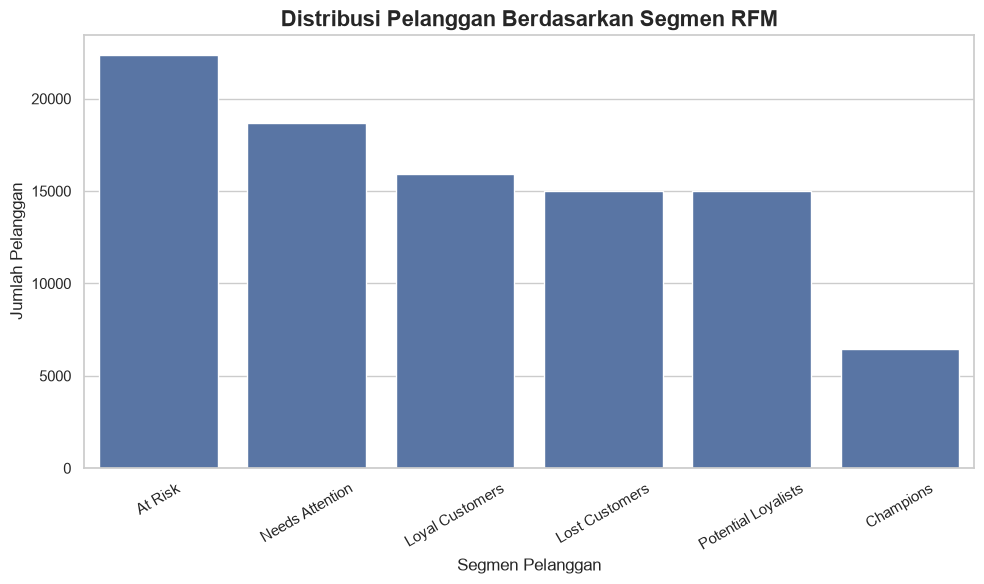

Segmen pelanggan terbesar: At Risk
Jumlah pelanggan: 22,357
Persentase: 23.95%


In [55]:
# Menggabungkan data transaksi dengan identitas pelanggan unik
rfm_data = sales[
    [
        'customer_id',
        'order_id',
        'order_purchase_timestamp',
        'sales_value'
    ]
].merge(
    customers_clean[
        [
            'customer_id',
            'customer_unique_id'
        ]
    ],
    on='customer_id',
    how='left'
)

rfm_data = rfm_data.dropna(
    subset=['customer_unique_id']
)

snapshot_date = (
    rfm_data['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

# Menghitung RFM berdasarkan customer_unique_id
rfm = (
    rfm_data
    .groupby('customer_unique_id')
    .agg(
        Recency=(
            'order_purchase_timestamp',
            lambda x: (
                snapshot_date - x.max()
            ).days
        ),
        Frequency=(
            'order_id',
            'nunique'
        ),
        Monetary=(
            'sales_value',
            'sum'
        )
    )
    .reset_index()
)

# Memberikan skor RFM
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

def segment_customer(row):

    if (
        row['R_Score'] >= 4
        and row['F_Score'] >= 4
        and row['M_Score'] >= 4
    ):
        return 'Champions'

    elif (
        row['R_Score'] >= 4
        and row['F_Score'] >= 3
    ):
        return 'Loyal Customers'

    elif (
        row['R_Score'] >= 4
        and row['F_Score'] <= 2
    ):
        return 'Potential Loyalists'

    elif (
        row['R_Score'] <= 2
        and row['F_Score'] >= 3
    ):
        return 'At Risk'

    elif (
        row['R_Score'] <= 2
        and row['F_Score'] <= 2
    ):
        return 'Lost Customers'

    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

rfm_segment = (
    rfm['Segment']
    .value_counts()
    .reset_index()
)

rfm_segment.columns = [
    'Segment',
    'Customers'
]

rfm_segment['Percentage'] = (
    rfm_segment['Customers']
    / rfm_segment['Customers'].sum()
    * 100
)

display(rfm.head())
display(rfm_segment)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rfm_segment,
    x='Segment',
    y='Customers'
)

plt.title(
    'Distribusi Pelanggan Berdasarkan Segmen RFM',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Segmen Pelanggan')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

largest_segment = rfm_segment.iloc[0]

print(
    "Segmen pelanggan terbesar:",
    largest_segment['Segment']
)

print(
    f"Jumlah pelanggan: {int(largest_segment['Customers']):,}"
)

print(
    f"Persentase: {largest_segment['Percentage']:.2f}%"
)

**Insight:** (Opsional)

- Berdasarkan hasil segmentasi RFM, segmen pelanggan terbesar adalah **At Risk** dengan jumlah **22.357 pelanggan atau 23,95% dari total pelanggan**. Hal ini menunjukkan cukup banyak pelanggan yang sebelumnya pernah melakukan transaksi, tetapi sudah tidak melakukan pembelian dalam periode terbaru.

- Segmen **Needs Attention** dan **Loyal Customers** juga memiliki jumlah pelanggan yang cukup besar. Kondisi ini menunjukkan bahwa terdapat peluang untuk mempertahankan pelanggan yang masih aktif sebelum mereka berpindah ke segmen dengan risiko kehilangan pelanggan yang lebih tinggi.

- Segmen **Champions** merupakan pelanggan dengan karakteristik Recency, Frequency, dan Monetary yang baik. Meskipun jumlahnya lebih sedikit dibandingkan segmen lain, pelanggan pada kelompok ini dapat menjadi prioritas dalam program loyalitas dan pemberian penawaran eksklusif.

- Pelanggan pada segmen **At Risk** dan **Lost Customers** perlu menjadi perhatian utama dalam strategi reaktivasi. Perusahaan dapat memberikan promosi personal, voucher, atau rekomendasi produk berdasarkan riwayat pembelian untuk mendorong pelanggan kembali melakukan transaksi.

- Secara keseluruhan, hasil segmentasi RFM menunjukkan bahwa strategi pemasaran tidak sebaiknya diterapkan secara sama kepada seluruh pelanggan. Setiap segmen memiliki karakteristik berbeda sehingga diperlukan pendekatan yang lebih terarah untuk meningkatkan retensi pelanggan dan mengurangi risiko kehilangan pelanggan.

## Conclusion & Recommendation

### Conclusion

- **Pertanyaan 1:** Analisis menunjukkan bahwa performa penjualan mengalami fluktuasi selama periode September 2016 hingga Agustus 2018. Nilai penjualan tertinggi terjadi pada **November 2017** dengan total sebesar **R$ 1.153.364,20**. Hasil ini menunjukkan bahwa terdapat periode dengan peningkatan permintaan yang signifikan sehingga pola penjualan bulanan perlu diperhatikan dalam perencanaan strategi promosi dan persediaan.

- **Pertanyaan 2:** Kategori **health_beauty** menghasilkan nilai penjualan terbesar dibandingkan kategori lainnya dengan total sebesar **R$ 1.412.089,53** atau sekitar **9,16% dari keseluruhan nilai penjualan**. Dominasi kategori ini menunjukkan bahwa produk pada kategori tersebut memiliki kontribusi penting terhadap pendapatan sehingga dapat menjadi salah satu prioritas dalam strategi promosi dan pengelolaan stok.

- **Analisis Lanjutan:** Segmentasi RFM menunjukkan bahwa pelanggan memiliki karakteristik transaksi yang berbeda berdasarkan Recency, Frequency, dan Monetary. Pelanggan dengan aktivitas transaksi tinggi dapat diprioritaskan dalam program retensi, sedangkan pelanggan pada segmen `At Risk` dan `Lost Customers` dapat menjadi target strategi reactivation untuk mendorong transaksi kembali.

**Rekomendasi Action Item:**

- Menggunakan November 2017 sebagai salah satu benchmark untuk mengevaluasi faktor yang mendorong tingginya nilai penjualan dan merancang campaign pada periode dengan potensi permintaan tinggi.
- Memprioritaskan kategori health_beauty dalam strategi promosi, pengelolaan stok, dan penawaran produk karena memberikan kontribusi nilai penjualan terbesar.
- Memberikan program loyalitas atau penawaran khusus kepada pelanggan pada segmen Champions dan Loyal Customers.
- Melakukan campaign reactivation yang lebih terarah kepada pelanggan pada segmen At Risk dan Lost Customers.
- Menggunakan dashboard untuk memantau tren penjualan, kategori produk, dan segmentasi pelanggan secara berkala sehingga keputusan bisnis dapat dibuat berdasarkan data.